# Titanic Survivor Prediction

## Project Overview
The objective of this project is to predict whether a passenger survived the Titanic disaster using machine learning techniques. The project includes data preprocessing, feature engineering, model training, hyperparameter tuning, and model evaluation using a Random Forest Classifier.

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Dataset

In [3]:
train_pd = pd.read_csv('data/train.csv')
test_pd = pd.read_csv('data/test.csv')

display(train_pd)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Separating the Target Variable

The target variable (`Survived`) is extracted from the training dataset and stored separately. The remaining features will be used as inputs for the machine learning model.

In [4]:
survived = train_pd['Survived']
train_pd = train_pd.drop(['Survived'], axis=1)

display(train_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Combining Training and Test Data

The training and test datasets are combined to ensure that preprocessing and feature engineering are applied consistently across both datasets.

In [5]:
train_idx = train_pd['PassengerId']
test_idx = test_pd['PassengerId']

combined_pd = pd.concat([train_pd, test_pd]).reset_index(drop=True)

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Identifying Missing Values

The dataset is inspected for missing values to determine which features require preprocessing before model training.

In [6]:
print('Null Values: ')
print(combined_pd.isnull().sum())

Null Values: 
PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


## Exploring Age Distribution

The distribution of passenger ages is visualized to better understand the dataset and support the strategy for handling missing age values.

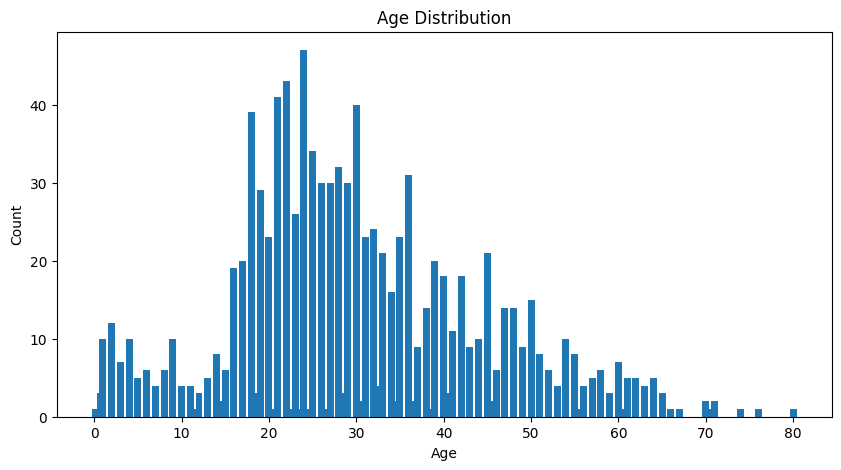

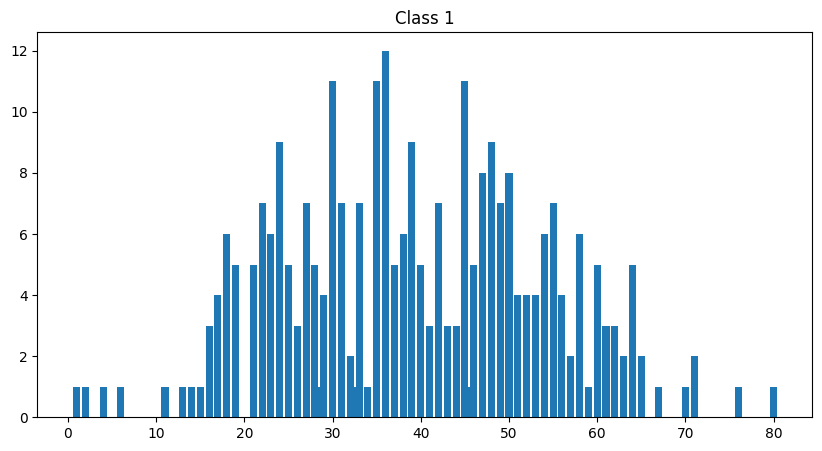

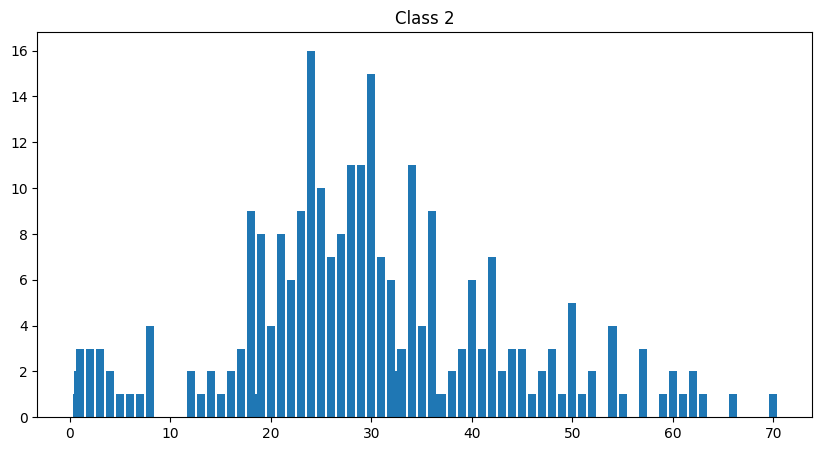

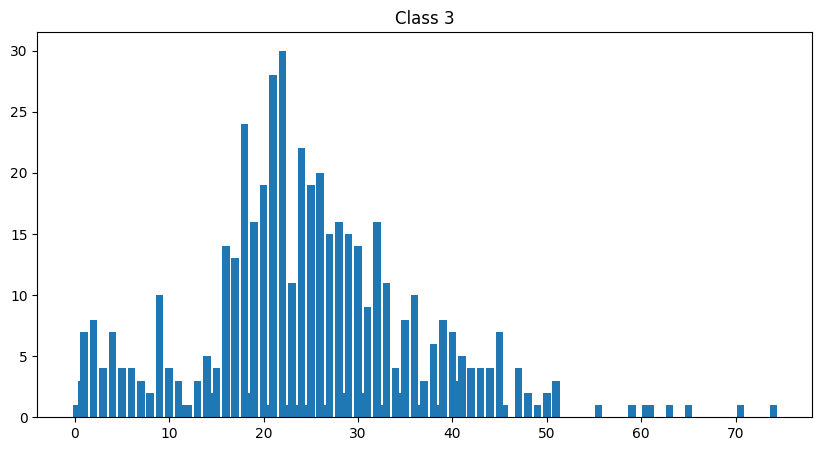

         Age
Pclass      
1       39.0
2       29.0
3       24.0


In [7]:
y = combined_pd['Age'].value_counts()
x = y.index.values

plt.figure(figsize=(10, 5))
plt.bar(x, y)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

class_age = combined_pd[['Pclass', 'Age']]

for i in range(1, 4):
    plt.figure(figsize=(10, 5))
    plt.title('Class ' + str(i))
    y = class_age[class_age['Pclass'] == i]['Age'].value_counts()
    x = y.index.values

    plt.bar(x, y)
    plt.show()

medians = class_age.groupby('Pclass').median()
print(medians)

## Handling Missing Age Values

Missing age values are replaced using the median age of each passenger class (`Pclass`). This preserves class-specific age patterns and reduces the effect of outliers.

In [8]:
for i in range(3):
    idx = np.where((combined_pd['Pclass'] == i + 1) & (combined_pd['Age'].isnull()))[0]
    combined_pd.loc[idx, 'Age'] = medians.values[i][0]

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S


## Handling Missing Fare Values

Missing fare values are replaced using the median fare of passengers with similar characteristics to maintain consistency within the dataset.

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


Median Fare for Class 3 passengers who embarked at Southampton: 8.05


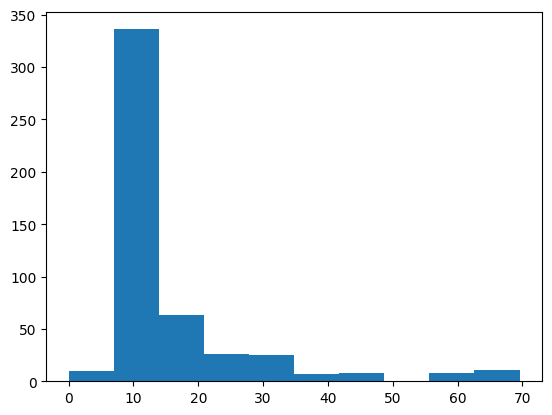

In [9]:
display(combined_pd[combined_pd['Fare'].isnull()])

sim_fares = combined_pd[(combined_pd['Pclass'] == 3) & (combined_pd['Embarked'] == 'S')]['Fare']
print('Median Fare for Class 3 passengers who embarked at Southampton:', sim_fares.median())

plt.hist(sim_fares)
plt.plot()

combined_pd['Fare'] = combined_pd['Fare'].fillna(sim_fares.median())

## Handling Missing Embarked Values

Missing embarkation ports are filled using information from passengers with similar ticket class and fare values.

In [10]:
display(combined_pd[combined_pd['Embarked'].isnull()])

sim_emb = combined_pd[(combined_pd['Pclass'] == 1) & (combined_pd['Fare'] >= 70) & (combined_pd['Fare'] <= 90)]['Embarked']
print(sim_emb.value_counts())

combined_pd['Embarked'] = combined_pd['Embarked'].fillna('C')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


Embarked
C    29
S    25
Q     3
Name: count, dtype: int64


## Processing Cabin Information

Missing cabin values are replaced with the placeholder value `M`. Only the first character of each cabin value is retained to represent the passenger's deck.

In [11]:
combined_pd['Cabin'] = combined_pd['Cabin'].fillna('M')
combined_pd['Cabin'] = combined_pd['Cabin'].str[0]

print(combined_pd['Cabin'].value_counts())

idx = np.where(combined_pd['Cabin'] == 'T')[0]
combined_pd.loc[idx, 'Cabin'] = 'M'

Cabin
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64


In [12]:
display(combined_pd)

print(combined_pd.isnull().sum())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [13]:
print(combined_pd.nunique())

print(combined_pd['Pclass'].unique())

PassengerId    1309
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin             8
Embarked          3
dtype: int64
[3 1 2]


## Extracting Name-Based Features

Passenger names are decomposed into last names, titles, and first names. Titles such as Mr, Mrs, Miss, and Master may contain useful information related to survival patterns.

In [14]:
print(combined_pd['Name'].unique())

names = combined_pd['Name']

last_names = []
titles = []
first_names = []

for name in names:
    if ', ' not in name:
        last_names.append('')
    else:
        last, name = name.split(', ', 1)
        last_names.append(last)

    if '. ' not in name:
        titles.append('')
    else:
        title, first = name.split('. ', 1)
        titles.append(title)
        first_names.append(first)

last_names = np.array(last_names)
titles = np.array(titles)
first_names = np.array(first_names)

idx = np.where(np.isin(titles, ['Capt', 'Col', 'Major']))
titles[idx] = 'Military'

idx = np.where(np.isin(titles, ['Don', 'Dona', 'Jonkheer', 'Lady', 'Sir', 'Master', 'the Countess']))
titles[idx] = 'Nobility'

idx = np.where(np.isin(titles, ['Miss', 'Mlle', 'Ms']))
titles[idx] = 'Ms'

idx = np.where(np.isin(titles, ['Mrs', 'Mme']))
titles[idx] = 'Mrs'

print('\n')
print(np.unique(titles, return_counts=True))

combined_pd['Titles'] = titles

display(combined_pd)


<ArrowStringArray>
[                            'Braund, Mr. Owen Harris',
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
                              'Heikkinen, Miss. Laina',
        'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
                            'Allen, Mr. William Henry',
                                    'Moran, Mr. James',
                             'McCarthy, Mr. Timothy J',
                      'Palsson, Master. Gosta Leonard',
   'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
                 'Nasser, Mrs. Nicholas (Adele Achem)',
 ...
                     'Riordan, Miss. Johanna Hannah""',
                           'Peacock, Miss. Treasteall',
                              'Naughton, Miss. Hannah',
     'Minahan, Mrs. William Edward (Lillian E Thorpe)',
                      'Henriksson, Miss. Jenny Lovisa',
                                  'Spector, Mr. Woolf',
                        'Oliva y Ocana, Dona. Fermina',
                        

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Titles
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr


## Creating Age Groups

Passenger ages are grouped into discrete age ranges using `pd.cut()`. Binning reduces noise and helps capture age-related survival trends.

In [15]:
print (combined_pd['Age'].min(), combined_pd['Age'].max())

bins = np.array([0,10,20,30,40,50,60,70,80])

combined_pd['Age_Bin'] = pd.cut(combined_pd['Age'], bins)

display(combined_pd)

0.17 80.0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Titles,Age_Bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]"
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]"
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]"
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]"


## Calculating Ticket Frequency

The number of passengers sharing each ticket is calculated. This feature may indicate whether passengers were travelling alone or as part of a group.

In [16]:
ticket_dict = dict(combined_pd['Ticket'].value_counts())

combined_pd['tkt_count'] = combined_pd['Ticket'].map(ticket_dict)

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Titles,Age_Bin,tkt_count
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1


## Creating Fare-Based Features

A new feature, `Fare_per_Ticket`, is created by dividing the ticket fare by the number of passengers sharing the ticket. The resulting values are grouped into fare ranges using binning.

0.0 128.0823


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Titles,Age_Bin,tkt_count,Fare_per_Ticket,Fare_Bin
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1,7.250000,"(0, 20]"
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2,35.641650,"(20, 40]"
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1,7.925000,"(0, 20]"
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2,26.550000,"(20, 40]"
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1,8.050000,"(0, 20]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]"
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3,36.300000,"(20, 40]"
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1,7.250000,"(0, 20]"
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]"


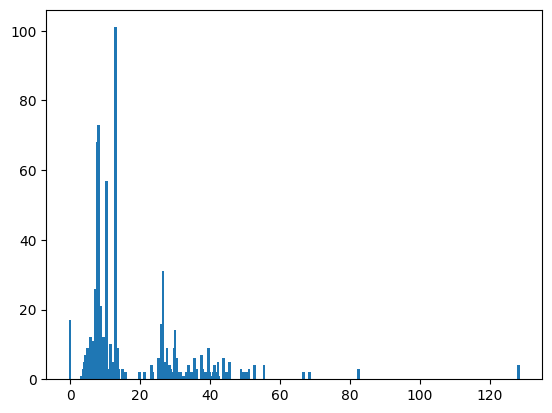

In [17]:
combined_pd['Fare_per_Ticket'] = combined_pd['Fare']/combined_pd['tkt_count']

plt.bar(combined_pd['Fare_per_Ticket'].value_counts().index.values, combined_pd['Fare_per_Ticket'].value_counts())
plt.show

print(combined_pd['Fare_per_Ticket'].min(), combined_pd['Fare_per_Ticket'].max())

bins = [0,20,40,60,80,150]
combined_pd['Fare_Bin'] = pd.cut(combined_pd['Fare_per_Ticket'], bins)

display(combined_pd)

## Creating Family Size Feature

Family size is calculated using the number of siblings/spouses (`SibSp`) and parents/children (`Parch`) accompanying each passenger.

Num_Family = SibSp + Parch + 1

In [18]:
combined_pd['Num_Family'] = combined_pd['SibSp'] + combined_pd['Parch'] + 1

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Titles,Age_Bin,tkt_count,Fare_per_Ticket,Fare_Bin,Num_Family
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,"(20, 30]",1,7.250000,"(0, 20]",2
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,"(30, 40]",2,35.641650,"(20, 40]",2
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Ms,"(20, 30]",1,7.925000,"(0, 20]",1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,"(30, 40]",2,26.550000,"(20, 40]",2
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,"(30, 40]",1,8.050000,"(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]",1
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,"(30, 40]",3,36.300000,"(20, 40]",1
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,"(30, 40]",1,7.250000,"(0, 20]",1
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,"(20, 30]",1,8.050000,"(0, 20]",1


## Removing Irrelevant Features

Columns that provide limited predictive value or contain highly unique values are removed to reduce noise and improve model performance.

In [19]:
combined_pd = combined_pd.drop(
    columns=['Name', 'Age', 'Ticket', 'Fare', 'tkt_count', 'Fare_per_Ticket']
)

display(combined_pd)

,PassengerId,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Titles,Age_Bin,Fare_Bin,Num_Family
0,1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
1,2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
2,3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
3,4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
4,5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1
1305,1306,1,female,0,0,C,C,Nobility,"(30, 40]","(20, 40]",1
1306,1307,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
1307,1308,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1


In [20]:
print(combined_pd.nunique())

PassengerId    1309
Pclass            3
Sex               2
SibSp             7
Parch             8
Cabin             8
Embarked          3
Titles            7
Age_Bin           8
Fare_Bin          5
Num_Family        9
dtype: int64


In [21]:
display(combined_pd)

,PassengerId,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Titles,Age_Bin,Fare_Bin,Num_Family
0,1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
1,2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
2,3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
3,4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
4,5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1
1305,1306,1,female,0,0,C,C,Nobility,"(30, 40]","(20, 40]",1
1306,1307,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
1307,1308,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1


In [22]:
import sklearn

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [24]:
combined_pd = combined_pd.set_index('PassengerId')

In [25]:
display(combined_pd)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Titles,Age_Bin,Fare_Bin,Num_Family
PassengerId,,,,,,,,,,
1,3,male,1,0,M,S,Mr,"(20, 30]","(0, 20]",2
2,1,female,1,0,C,C,Mrs,"(30, 40]","(20, 40]",2
3,3,female,0,0,M,S,Ms,"(20, 30]","(0, 20]",1
4,1,female,1,0,C,S,Mrs,"(30, 40]","(20, 40]",2
5,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1
...,...,...,...,...,...,...,...,...,...,...
1305,3,male,0,0,M,S,Mr,"(20, 30]","(0, 20]",1
1306,1,female,0,0,C,C,Nobility,"(30, 40]","(20, 40]",1
1307,3,male,0,0,M,S,Mr,"(30, 40]","(0, 20]",1


## Label Encoding

Categorical features are converted into numerical values using Label Encoding so that they can be processed by machine learning algorithms.

In [26]:
from sklearn.preprocessing import LabelEncoder
import joblib

label_enc = combined_pd.copy().astype(str)
encoders = {}

for col in label_enc.columns:
    le = LabelEncoder()
    label_enc[col] = le.fit_transform(label_enc[col])
    encoders[col] = le

joblib.dump(encoders, 'label_encoders.pkl')
display(label_enc)

,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Titles,Age_Bin,Fare_Bin,Num_Family
PassengerId,,,,,,,,,,
1,2,1,1,0,7,2,2,2,0,2
2,0,0,1,0,2,0,3,3,1,2
3,2,0,0,0,7,2,4,2,0,0
4,0,0,1,0,2,2,3,3,1,2
5,2,1,0,0,7,2,2,3,0,0
...,...,...,...,...,...,...,...,...,...,...
1305,2,1,0,0,7,2,2,2,0,0
1306,0,0,0,0,2,0,5,3,1,0
1307,2,1,0,0,7,2,2,3,0,0


## One-Hot Encoding

Selected categorical variables are transformed using One-Hot Encoding to prevent the model from assuming ordinal relationships between categories.

In [27]:
one_hot = label_enc.copy()

one_hot = pd.get_dummies(one_hot, columns=['Sex', 'Embarked', 'Titles'])
one_hot = one_hot.astype(int)

display(one_hot)

,Pclass,SibSp,Parch,Cabin,Age_Bin,Fare_Bin,Num_Family,Sex_0,Sex_1,Embarked_0,Embarked_1,Embarked_2,Titles_0,Titles_1,Titles_2,Titles_3,Titles_4,Titles_5,Titles_6
PassengerId,,,,,,,,,,,,,,,,,,,
1,2,1,0,7,2,0,2,0,1,0,0,1,0,0,1,0,0,0,0
2,0,1,0,2,3,1,2,1,0,1,0,0,0,0,0,1,0,0,0
3,2,0,0,7,2,0,0,1,0,0,0,1,0,0,0,0,1,0,0
4,0,1,0,2,3,1,2,1,0,0,0,1,0,0,0,1,0,0,0
5,2,0,0,7,3,0,0,0,1,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,2,0,0,7,2,0,0,0,1,0,0,1,0,0,1,0,0,0,0
1306,0,0,0,2,3,1,0,1,0,1,0,0,0,0,0,0,0,1,0
1307,2,0,0,7,3,0,0,0,1,0,0,1,0,0,1,0,0,0,0


## Data Preparation and Train-Test Split

The processed dataset is scaled using Min-Max Scaling and divided into training and testing sets. The testing set is reserved for evaluating model performance on unseen data.

In [28]:
x = one_hot.loc[train_idx].values
y = survived.values

scaler = MinMaxScaler()
scaler.fit(x)
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=0)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(712, 19) (179, 19) (712,) (179,)


## Training the Baseline Random Forest Model

A Random Forest Classifier is trained as the baseline model. Its performance serves as a reference before hyperparameter optimization.

In [29]:
clf = RandomForestClassifier(random_state=0)
clf.fit(x_train, y_train).score(x_test, y_test)

0.7932960893854749

## Hyperparameter Tuning with Randomized Search

RandomizedSearchCV is used to explore a wide range of Random Forest hyperparameters and identify promising parameter combinations.

In [30]:
params = {'criterion':['gini','entropy'],
          'n_estimators' : [20,50,100,200,300,400,500,800,1000],
          'max_depth': np.arange(3,50),
          'min_samples_split': np.arange(1,1000),
          'max_features' : ['sqrt', 'log2'],
          'max_samples' : np.linspace(0.1,0.9,10)}

rand_search = RandomizedSearchCV(RandomForestClassifier(random_state=0), params, scoring='accuracy', random_state=0, cv=5)
rand_search.fit(x_train, y_train)

rand_params = rand_search.best_params_
print(rand_params, '\n')
print('Trian Acc:', rand_search.best_score_)
preds = rand_search.predict(x_test)
print('Test Acc:', accuracy_score(preds, y_test))

{'n_estimators': 200, 'min_samples_split': np.int64(16), 'max_samples': np.float64(0.6333333333333333), 'max_features': 'sqrt', 'max_depth': np.int64(49), 'criterion': 'gini'} 

Trian Acc: 0.8286417807544568
Test Acc: 0.8268156424581006


## Hyperparameter Refinement with Grid Search

GridSearchCV performs a more focused search around the best parameters identified by RandomizedSearchCV to further improve model performance.

In [31]:
n_estimators = np.linspace(rand_params['n_estimators']-10, rand_params['n_estimators']+10, 3).astype(int)

min_samples_split = np.arange(rand_params['min_samples_split']-3, rand_params['min_samples_split']+3).astype(int)

max_samples =np.linspace(rand_params['max_samples']-.05, rand_params['max_samples']+.05, 6)

max_depth = np.arange(rand_params['max_depth']-5, rand_params['max_depth']+5).astype(int)


params = {'criterion': [rand_params['criterion']],
          'n_estimators' : n_estimators,
          'max_depth': max_depth,
          'min_samples_split': min_samples_split,
          'max_features' : [rand_params['max_features']],
          'max_samples' : max_samples}

grid_search = GridSearchCV(RandomForestClassifier(random_state=0), params, scoring='accuracy', cv=5)
grid_search.fit(x_train, y_train)

grid_params = grid_search.best_params_
print(grid_params, '\n')
print('Trian Acc:', grid_search.best_score_)
preds = grid_search.predict(x_test)
print('Test Acc:', accuracy_score(preds, y_test))

{'criterion': 'gini', 'max_depth': np.int64(44), 'max_features': 'sqrt', 'max_samples': np.float64(0.6033333333333333), 'min_samples_split': np.int64(15), 'n_estimators': np.int64(210)} 

Trian Acc: 0.8342558849601103
Test Acc: 0.8268156424581006


In [32]:
import joblib

final_model = grid_search.best_estimator_

joblib.dump(final_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(one_hot.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

## Conclusion

A complete machine learning pipeline was developed for Titanic survival prediction. The project included missing value treatment, feature engineering, categorical encoding, scaling, model training, and hyperparameter optimization. The final Random Forest model achieved strong predictive performance and demonstrates the application of supervised machine learning techniques on tabular data.